In [144]:
import numpy as np
import numpy as np
import torch
import matplotlib.pyplot as plt
import py_vollib_vectorized
import os

from configs.analysis_heston.full_heston_config_1 import FullConfig
from configs.base.env_cfg import device, torch_dtype
from utils.log_print import LogPrint
from utils.pricing import QuantLibHestonModel

from  utils.pricing import bs_delta_from_iv, heston_delta_slice
from utils.analysis import bootstrap_implied_vol, plot_iv_smile
from utils.pricing import bs_delta_from_iv
from src.data_processing import make_state_t
from utils.model_saver import (
    load_market_and_critic0,
    load_actor,
    load_critic_lambda
)
from src.rl_models import q_diff_risk_lambda, q_diff_critic_risk_lambda
# === 核心替换：我们自己的 Heston / FFT / MC ===
from src.heston_model import sim_heston_paths
from utils.pricing import fft_option_prices, fft_bump_delta


In [145]:
LOAD_DIR = (
    "models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5_trans_cost0"
)
# LOAD_DIR = (
#     "models/heston_V00_04__kappa4_0__theta0_035__sigma0_3__rho_0_35"
# )

In [146]:
K_GRID = np.linspace(70, 130, 100)
K_GRID = np.linspace(75, 125, 100)
LAMBDA_GRID = [
    0, 0.5, 5, 20, 50,
]
ACTOR_LAMBDA = 100_000

In [147]:
# =============================================================================
# Load market, actor, critic0
# =============================================================================
log_print = LogPrint(
    print_debug=True,
    save_dir=os.path.join(LOAD_DIR, "logs"),
    prefix="analysis_section_4_1",
)
with torch.no_grad():

    critic0, market_cfg, critic0_cfg, runtime_cfg = load_market_and_critic0(
        log_print=log_print,
        load_dir=LOAD_DIR,
        device=device,
        torch_dtype=torch_dtype,
    )

    actor, actor_cfg = load_actor(
        log_print=log_print,
        load_dir=LOAD_DIR,
        actor_lambda=ACTOR_LAMBDA,
        device=device,
        torch_dtype=torch_dtype,
    )
    critic, critic_cfg = load_critic_lambda(
            log_print=log_print,
            load_dir=LOAD_DIR,
            actor_lambda=ACTOR_LAMBDA,
            critic_lambda=ACTOR_LAMBDA,
            device=device,
            torch_dtype=torch_dtype,
    )


当前工作目录：/Users/hy/PycharmProjects/qlbs_rl
当前已是qlbs_rl根目录，无需切换
[MarketArtifactLoader] Loaded market artifact: 
path            : models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5_trans_cost0
  - MarketCFG   : market_cfg.json
  - Critic0     : critic0.pt
  - RuntimeCFG  : runtime_cfg.json

[ActorLoader] Loaded actor λ=100000
  path: models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5_trans_cost0/actor_lambda_100000.0000/actor.pt
  device: mps, dtype: torch.float32
[CriticLoader] Loaded critic λ=100000
  path: models/heston_V00_04__kappa1_5__theta0_04__sigma0_25__rho_0_5_trans_cost0/actor_lambda_100000.0000/critic_100000.0000.pt
  device: mps


In [148]:
S0 = market_cfg.S0
V0 = market_cfg.V0

mu = market_cfg.mu
kappa= market_cfg.kappa
theta = market_cfg.theta
sigma = market_cfg.sigma
rho = market_cfg.rho

r = market_cfg.r
T = market_cfg.T
# T = 0.5
T_steps = market_cfg.T_steps
K = market_cfg.S0             # ATM
option_type = "put"           # 保持不变


In [149]:

@torch.no_grad()
def acc_slice(
        actor, critic0, critic,
        S0,
        K_GRID,
        actor_risk_lambda: float,
        all_critic_risk_lambda: list,
        t,
        device, torch_dtype,
):
    K_GRID = torch.tensor(K_GRID, device=device, dtype=torch_dtype)
    S_over_K = S0 / K_GRID
    state = make_state_t(
        torch.tensor(S_over_K, device=device, dtype=torch_dtype),
        torch.tensor(t, device=device, dtype=torch_dtype),
    )
    actions = actor.mean(state)

    # state.repeat(50, 1, 1)

    QQ = q_diff_critic_risk_lambda(
        critic0=critic0,
        critic=critic,
        actions=actions,
        actor_risk_lambda=actor_risk_lambda,
        all_critic_risk_lambda=all_critic_risk_lambda,
        state=state,
    )

    return - QQ * K_GRID, actions * (K_GRID / S0)

all_q, actions = acc_slice(
    actor, critic0, critic,
    S0,
    K_GRID,
    actor_risk_lambda = ACTOR_LAMBDA,
    all_critic_risk_lambda = LAMBDA_GRID,
    t = T,
    device=device,
    torch_dtype=torch_dtype,
)
all_q = all_q[:,0]


/var/folders/sl/0y225v_53s51ql32byt5jkcm0000gn/T/ipykernel_82534/1602730966.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(S_over_K, device=device, dtype=torch_dtype),


In [150]:
K_tensor = torch.tensor(K_GRID, device=device, dtype=torch_dtype)

S_tensor = torch.full_like(K_tensor, S0, device=device, dtype=torch_dtype)
V_tensor = torch.full_like(K_tensor, V0, device=device, dtype=torch_dtype)
T_tensor = torch.full_like(K_tensor, T, device=device, dtype=torch_dtype)
r_tensor = torch.full_like(K_tensor, r, device=device, dtype=torch_dtype)
kappa = torch.full_like(K_tensor, kappa, device=device, dtype=torch_dtype)
theta = torch.full_like(K_tensor, theta, device=device, dtype=torch_dtype)
sigma = torch.full_like(K_tensor, sigma, device=device, dtype=torch_dtype)
rho = torch.full_like(K_tensor, rho, device=device, dtype=torch_dtype)
option_types = torch.full_like(K_tensor, 0, device=device)
# price_fft = fft_option_prices(
#     S=S_tensor,
#     V=V_tensor,
#     K=K_tensor,
#     T=T_tensor,
#     r=r_tensor,
#     kappa=kappa,
#     theta = theta,
#     sigma=sigma,
#     rho=rho,
#     option_types=option_types,
# ).cpu().numpy()
#
# iv_fft = py_vollib_vectorized.vectorized_implied_volatility(
#     price=price_fft,
#     S=S0,
#     K=K_GRID,
#     t=T,
#     r=r,
#     q=0,
#     flag='p',
#     model="black_scholes_merton",
#     on_error="ignore",
#     return_as="numpy",
# )

In [151]:
ql_heston_model = QuantLibHestonModel(
    market_cfg=market_cfg,
    engine_type="analytic",
)
ql_price = np.array([
    ql_heston_model._analytic_price(
        S_t=S0,
        V_t=V0,
        K=K,
        tau=T,
    )
    for K in K_GRID
])

ql_delta = heston_delta_slice(
    heston_model=ql_heston_model,
    S0=S0,
    v0=V0,
    K_array=K_GRID,
    T=T,
)
ql_iv = py_vollib_vectorized.vectorized_implied_volatility(
    price=ql_price,
    S=S0,
    K=K_GRID,
    t=T,
    r=r,
    q=0,
    flag='p',
    model="black_scholes_merton",
    on_error="ignore",
    return_as="numpy",
)

In [152]:
np.full_like(ql_price,0)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [153]:
diff_price_all = {
}
price_all = {
    # 'heston price': price_fft,
    'ql heston price': ql_price,
}
delta_all = {
    'ql delta': ql_delta,
    'ACC-Actor Actions': actions.cpu().numpy(),
}
iv_all = {
    # 'heston fft': iv_fft,
    'ql heston': ql_iv,
}
for i, L in enumerate(LAMBDA_GRID):
    prices = all_q[i].cpu().numpy()
    diff_price_all[f'Price Diff ACC-Critic L={L}'] = (prices - ql_price)
    price_all[f'Price ACC-Critic L={L}'] = prices
    iv_all[f'IV ACC-Critic L={L}'] = py_vollib_vectorized.vectorized_implied_volatility(
                price=prices,
                S=S0,
                K=K_GRID,
                t=T,
                r=r,
                q=0,
                flag='p',
                model="black_scholes_merton",
                on_error="ignore",
                return_as="numpy",
            )

In [154]:
K_GRID

array([ 75.        ,  75.50505051,  76.01010101,  76.51515152,
        77.02020202,  77.52525253,  78.03030303,  78.53535354,
        79.04040404,  79.54545455,  80.05050505,  80.55555556,
        81.06060606,  81.56565657,  82.07070707,  82.57575758,
        83.08080808,  83.58585859,  84.09090909,  84.5959596 ,
        85.1010101 ,  85.60606061,  86.11111111,  86.61616162,
        87.12121212,  87.62626263,  88.13131313,  88.63636364,
        89.14141414,  89.64646465,  90.15151515,  90.65656566,
        91.16161616,  91.66666667,  92.17171717,  92.67676768,
        93.18181818,  93.68686869,  94.19191919,  94.6969697 ,
        95.2020202 ,  95.70707071,  96.21212121,  96.71717172,
        97.22222222,  97.72727273,  98.23232323,  98.73737374,
        99.24242424,  99.74747475, 100.25252525, 100.75757576,
       101.26262626, 101.76767677, 102.27272727, 102.77777778,
       103.28282828, 103.78787879, 104.29292929, 104.7979798 ,
       105.3030303 , 105.80808081, 106.31313131, 106.81

In [155]:
def plot_img(x_grid, all_data, title, xlabel='Strike Price', ylabel='BS Implied Volatility'):

    import matplotlib.pyplot as plt
    import numpy as np
    # 画图
    plt.figure(figsize=(10, 5))

    # 遍历字典，每条线画一次
    for name, data in all_data.items():
        plt.plot(x_grid, data, label=name)  # label 就是图例名字

    # 加上图例、标签
    plt.legend()          # 显示每条线名字
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()


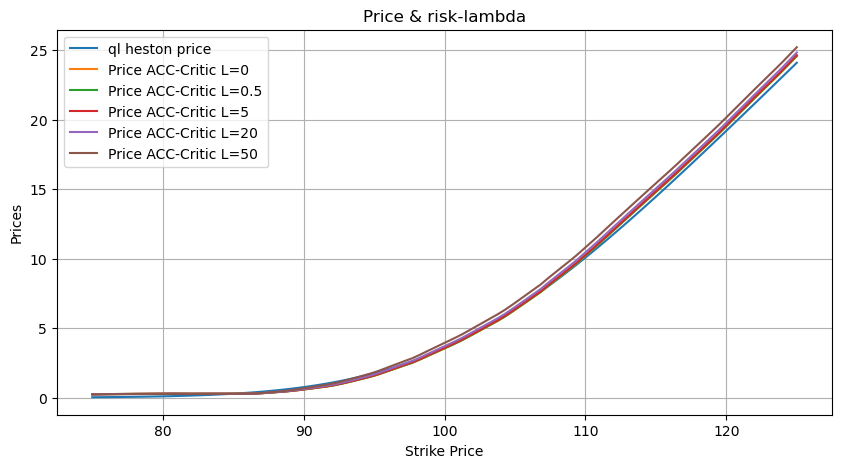

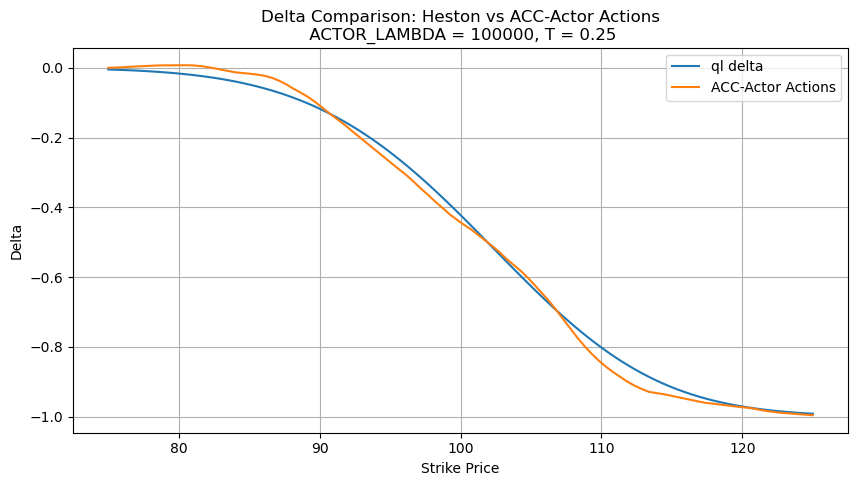

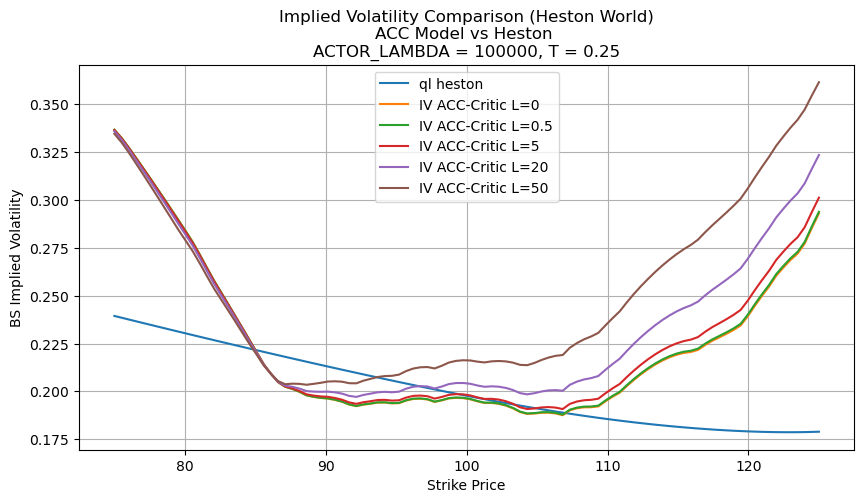

In [163]:
plot_img(K_GRID, price_all, "Price & risk-lambda", xlabel='Strike Price', ylabel='Prices')
plot_img(K_GRID, delta_all,
         f"Delta Comparison: Heston vs ACC-Actor Actions\n ACTOR_LAMBDA = {ACTOR_LAMBDA}, T = {T}",
         xlabel='Strike Price',
         ylabel='Delta',
         )
plot_img(K_GRID, iv_all,
        "Implied Volatility Comparison (Heston World)\n"
        f"ACC Model vs Heston \n"
        f"ACTOR_LAMBDA = {ACTOR_LAMBDA}, T = {T}"
         )


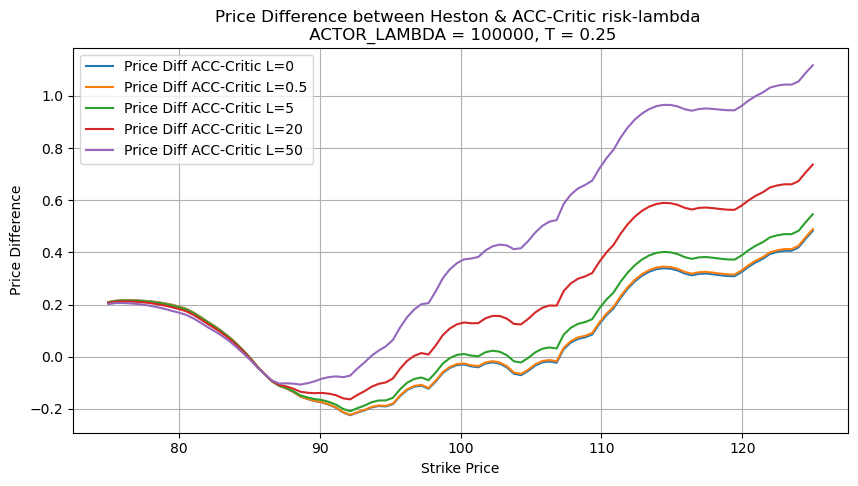

In [161]:
plot_img(K_GRID, diff_price_all, f"Price Difference between Heston & ACC-Critic risk-lambda \n ACTOR_LAMBDA = {ACTOR_LAMBDA}, T = {T}", xlabel='Strike Price', ylabel='Price Difference')


In [164]:
price_all

{'ql heston price': array([2.30109673e-02, 2.65229957e-02, 3.05146710e-02, 3.50428974e-02,
        4.01701191e-02, 4.59647017e-02, 5.25013213e-02, 5.98613571e-02,
        6.81332858e-02, 7.74130744e-02, 8.78045671e-02, 9.94198625e-02,
        1.12379678e-01, 1.26813694e-01, 1.42860876e-01, 1.60669766e-01,
        1.80398740e-01, 2.02216223e-01, 2.26300859e-01, 2.52841629e-01,
        2.82037901e-01, 3.14099425e-01, 3.49246245e-01, 3.87708540e-01,
        4.29726373e-01, 4.75549357e-01, 5.25436215e-01, 5.79654253e-01,
        6.38478712e-01, 7.02192032e-01, 7.71082988e-01, 8.45445729e-01,
        9.25578700e-01, 1.01178346e+00, 1.10436339e+00, 1.20362229e+00,
        1.30986293e+00, 1.42338542e+00, 1.54448562e+00, 1.67345335e+00,
        1.81057071e+00, 1.95611016e+00, 2.11033279e+00, 2.27348639e+00,
        2.44580368e+00, 2.62750049e+00, 2.81877403e+00, 3.01980119e+00,
        3.23073702e+00, 3.45171325e+00, 3.68283697e+00, 3.92418951e+00,
        4.17582545e+00, 4.43777184e+00, 4.710